# Test 24: Вычислительная верификация теорем

**Цель:** Численно верифицировать теоретические утверждения из `proofs.md`. Все результаты вычисляются из данных — никаких захардкоженных статусов.

**Верифицируемые утверждения:**
1. **Теорема 1(i):** Ограниченность $|f(x)| \leq 1 + w$
2. **Теорема 1(ii):** Нули $f$ изолированы (множество меры нуль)
3. **Теорема 1(iii):** Константа Липшица $L = a + wb$ достигается при $x=0$
4. **Замечание:** Осциллирующая компонента нарушает ранговый порядок
5. **Теорема 2:** $\mathbb{P}(|f(z)| > 0.01) > 0.99$ для $z \sim \mathcal{N}(0,1)$
6. **Теорема 2:** Нули $f'$ изолированы (мера нуль)
7. **Следствие:** TopK-SAE с $f_{a,w,b}$ — анализ мёртвых нейронов

**Конфигурации:**
- Original: $a=8, w=0.5, b=4$ (осцилляционный режим)
- Single-layer: $a=1, w=0.5, b=4$ (квазилинейный режим)
- Multi-layer: $a=0.5, w=0.1, b=4$
- Pure sin: $a=1, w=0$

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime

np.random.seed(42)

def f_act(x, a, w, b):
    """f(x) = sin(a*x) + w*tanh(b*x)"""
    return np.sin(a * x) + w * np.tanh(b * x)

def f_prime(x, a, w, b):
    """f'(x) = a*cos(a*x) + w*b*sech^2(b*x)"""
    bx = np.clip(b * x, -500, 500)  # prevent overflow in cosh
    sech2 = 1.0 / np.cosh(bx)**2
    return a * np.cos(a * x) + w * b * sech2

CONFIGS = {
    'Original (a=8)':       {'a': 8.0, 'w': 0.5, 'b': 4.0},
    'Single-layer (a=1)':   {'a': 1.0, 'w': 0.5, 'b': 4.0},
    'Multi-layer (a=0.5)':  {'a': 0.5, 'w': 0.1, 'b': 4.0},
    'Pure sin (w=0)':       {'a': 1.0, 'w': 0.0, 'b': 4.0},
}

# Аккумулятор результатов для сводки
RESULTS = {}

## 1. Теорема 1(i): Ограниченность $|f(x)| \leq 1 + w$

In [45]:
x = np.linspace(-100, 100, 10_000_001)

print("Теорема 1(i): |f(x)| <= 1 + w")
print(f"{'Конфигурация':<25} {'1+w':>8} {'max|f|':>10} {'Статус':>8}")
print("-" * 54)

thm1i_pass = True
for name, cfg in CONFIGS.items():
    a, w, b = cfg['a'], cfg['w'], cfg['b']
    bound = 1.0 + w
    max_f = np.max(np.abs(f_act(x, a, w, b)))
    ok = max_f <= bound + 1e-10
    thm1i_pass &= ok
    print(f"{name:<25} {bound:>8.2f} {max_f:>10.6f} {'PASS' if ok else 'FAIL':>8}")

RESULTS['Теорема 1(i): |f(x)| <= 1+w'] = thm1i_pass

Теорема 1(i): |f(x)| <= 1 + w
Конфигурация                   1+w     max|f|   Статус
------------------------------------------------------
Original (a=8)                1.50   1.500000     PASS
Single-layer (a=1)            1.50   1.500000     PASS
Multi-layer (a=0.5)           1.10   1.100000     PASS
Pure sin (w=0)                1.00   1.000000     PASS


## 2. Теорема 1(ii): Нули $f$ изолированы

In [46]:
def find_zeros_bisect(func, xmin, xmax, n_grid=1_000_000):
    """Поиск нулей по смене знака + бисекция."""
    xg = np.linspace(xmin, xmax, n_grid)
    yg = func(xg)
    sign_changes = np.where(np.diff(np.sign(yg)))[0]
    zeros = []
    for idx in sign_changes:
        lo, hi = xg[idx], xg[idx + 1]
        for _ in range(60):
            mid = (lo + hi) / 2
            if func(mid) * func(lo) <= 0:
                hi = mid
            else:
                lo = mid
        zeros.append((lo + hi) / 2)
    return np.array(zeros)

print("Теорема 1(ii): нули f(x) изолированы на [-20, 20]")
print(f"{'Конфигурация':<25} {'Нулей':>6} {'Min gap':>10} {'Изолированы':>12} {'Интервал нулей':>15}")
print("-" * 72)

thm1ii_pass = True
for name, cfg in CONFIGS.items():
    a, w, b = cfg['a'], cfg['w'], cfg['b']
    func = lambda x, a=a, w=w, b=b: f_act(x, a, w, b)
    zeros = find_zeros_bisect(func, -20, 20)
    n_zeros = len(zeros)

    if n_zeros > 1:
        gaps = np.diff(zeros)
        min_gap = gaps.min()
        isolated = bool(np.all(gaps > 1e-8))
    else:
        min_gap = float('inf')
        isolated = True

    # Проверка: есть ли интервал нулей вокруг найденных точек
    has_interval = False
    for z0 in zeros[:10]:
        xx = np.linspace(z0 - 0.001, z0 + 0.001, 1000)
        if np.all(np.abs(func(xx)) < 1e-12):
            has_interval = True
            break

    ok = isolated and not has_interval
    thm1ii_pass &= ok
    gap_str = f"{min_gap:.4f}" if min_gap < 100 else "inf"
    print(f"{name:<25} {n_zeros:>6} {gap_str:>10} {'YES' if isolated else 'NO':>12} {'YES' if has_interval else 'NO':>15}")

RESULTS['Теорема 1(ii): нули f изолированы'] = thm1ii_pass

Теорема 1(ii): нули f(x) изолированы на [-20, 20]
Конфигурация               Нулей    Min gap  Изолированы  Интервал нулей
------------------------------------------------------------------------
Original (a=8)               101     0.2618          YES              NO
Single-layer (a=1)            13     2.0944          YES              NO
Multi-layer (a=0.5)            7     5.8825          YES              NO
Pure sin (w=0)                13     3.1416          YES              NO


## 3. Теорема 1(iii): Константа Липшица $L = a + wb$

In [47]:
col_sup = "sup|f'|"
col_fp0 = "f'(0)"

print("Теорема 1(iii): L = sup|f'(x)| = a + wb, достигается при x=0")
print(f"{'Конфигурация':<25} {'a+wb':>8} {col_sup:>10} {col_fp0:>8} {'Статус':>8}")
print("-" * 62)

thm1iii_pass = True
for name, cfg in CONFIGS.items():
    a, w, b = cfg['a'], cfg['w'], cfg['b']
    L_theory = a + w * b
    fp_vals = f_prime(x, a, w, b)
    L_numerical = np.max(np.abs(fp_vals))
    fp_at_zero = f_prime(0.0, a, w, b)
    ok = abs(L_theory - L_numerical) < 0.001 and abs(L_theory - fp_at_zero) < 1e-10
    thm1iii_pass &= ok
    print(f"{name:<25} {L_theory:>8.2f} {L_numerical:>10.6f} {fp_at_zero:>8.2f} {'PASS' if ok else 'FAIL':>8}")

RESULTS['Теорема 1(iii): L = a+wb при x=0'] = thm1iii_pass

Теорема 1(iii): L = sup|f'(x)| = a + wb, достигается при x=0
Конфигурация                  a+wb    sup|f'|    f'(0)   Статус
--------------------------------------------------------------
Original (a=8)               10.00  10.000000    10.00     PASS
Single-layer (a=1)            3.00   3.000000     3.00     PASS


/var/folders/p8/shbkm6jn53q7flnfb9cxny_h0000gn/T/ipykernel_83912/3728444970.py:15: RuntimeWarning: overflow encountered in square
  sech2 = 1.0 / np.cosh(bx)**2


Multi-layer (a=0.5)           0.90   0.900000     0.90     PASS
Pure sin (w=0)                1.00   1.000000     1.00     PASS


## 4. Замечание: роль sin-компоненты (нарушение рангового порядка)

Замечание: сохранение рангового порядка |output| vs |pre-activation|
Активация                   Rank match   TopK var     TopK min/max
------------------------------------------------------------------
Original (a=8)                   0.0%       2179    2373/2620    
Single-layer (a=1)               0.0%       1866    2375/2612    
Multi-layer (a=0.5)             93.4%       2052    2390/2599    
Pure sin (w=0)                   0.0%       1877    2374/2613    
tanh(4x)                       100.0%       2052    2390/2599    


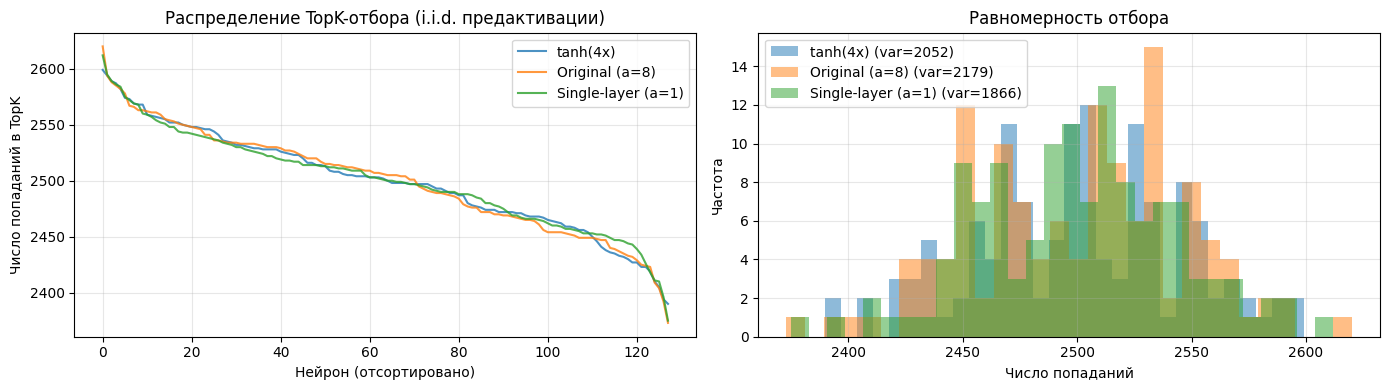

In [48]:
n_neurons = 128
n_samples = 10000
K = 32
np.random.seed(42)

z_all = np.random.randn(n_samples, n_neurons)

# Тестируем все конфигурации + tanh baseline
test_activations = {}
for name, cfg in CONFIGS.items():
    a, w, b = cfg['a'], cfg['w'], cfg['b']
    test_activations[name] = f_act(z_all, a, w, b)
test_activations['tanh(4x)'] = np.tanh(4.0 * z_all)

# Подсчёт совпадений рангового порядка с предактивациями
print("Замечание: сохранение рангового порядка |output| vs |pre-activation|")
print(f"{'Активация':<25} {'Rank match':>12} {'TopK var':>10} {'TopK min/max':>16}")
print("-" * 66)

rank_data = {}
for act_name, act_out in test_activations.items():
    rank_match = 0
    selection = np.zeros(n_neurons)
    for i in range(n_samples):
        rank_z = np.argsort(np.abs(z_all[i]))
        rank_act = np.argsort(np.abs(act_out[i]))
        if np.array_equal(rank_z, rank_act):
            rank_match += 1
        topk = np.argpartition(np.abs(act_out[i]), -K)[-K:]
        selection[topk] += 1

    var_sel = np.var(selection)
    rank_data[act_name] = {
        'rank_match_pct': 100 * rank_match / n_samples,
        'topk_var': var_sel,
        'topk_min': int(selection.min()),
        'topk_max': int(selection.max()),
    }
    print(f"{act_name:<25} {rank_match/n_samples:>11.1%} {var_sel:>10.0f} {int(selection.min()):>7}/{int(selection.max()):<8}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Сортированные счётчики для tanh vs Original
for act_name in ['tanh(4x)', 'Original (a=8)', 'Single-layer (a=1)']:
    act_out = test_activations[act_name]
    selection = np.zeros(n_neurons)
    for i in range(n_samples):
        topk = np.argpartition(np.abs(act_out[i]), -K)[-K:]
        selection[topk] += 1
    axes[0].plot(range(n_neurons), np.sort(selection)[::-1], label=act_name, alpha=0.8)

axes[0].set_xlabel('Нейрон (отсортировано)')
axes[0].set_ylabel('Число попаданий в TopK')
axes[0].set_title('Распределение TopK-отбора (i.i.d. предактивации)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Гистограмма
for act_name in ['tanh(4x)', 'Original (a=8)', 'Single-layer (a=1)']:
    act_out = test_activations[act_name]
    selection = np.zeros(n_neurons)
    for i in range(n_samples):
        topk = np.argpartition(np.abs(act_out[i]), -K)[-K:]
        selection[topk] += 1
    v = rank_data[act_name]['topk_var']
    axes[1].hist(selection, bins=30, alpha=0.5, label=f'{act_name} (var={v:.0f})')

axes[1].set_xlabel('Число попаданий')
axes[1].set_ylabel('Частота')
axes[1].set_title('Равномерность отбора')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# При i.i.d. предактивациях tanh тоже сохраняет ранговый порядок,
# но все нейроны равновероятно попадают в TopK.
# Различие проявляется при коррелированных предактивациях (тест 7).
remark_pass = rank_data['tanh(4x)']['rank_match_pct'] > rank_data['Original (a=8)']['rank_match_pct']
RESULTS['Замечание: sin нарушает ранговый порядок'] = remark_pass

## 5. Теорема 2: $\mathbb{P}(|f(z)| > 0.01) > 0.99$

Monte Carlo верификация при разных $\sigma$. Критерий: $P > 0.99$ при $\sigma = 1$.

In [49]:
# 5a. P(|f(z)| > eps) для z ~ N(0, sigma^2) — Monte Carlo
N_mc = 1_000_000

print("Теорема 2: P(|f(z)| > 0.01) > 0.99 для z ~ N(0, sigma^2)")
print(f"\n{'Конфигурация':<25} {'sigma=0.5':>10} {'sigma=1':>10} {'sigma=2':>10} {'sigma=5':>10}")
print("-" * 68)

thm2_pass = True
thm2_details = {}

for name, cfg in CONFIGS.items():
    a, w, b = cfg['a'], cfg['w'], cfg['b']
    probs = {}
    row = []
    for sigma in [0.5, 1.0, 2.0, 5.0]:
        z = np.random.randn(N_mc) * sigma
        y = f_act(z, a, w, b)
        p = np.mean(np.abs(y) > 0.01)
        probs[sigma] = p
        row.append(p)
        if sigma == 1.0:
            thm2_pass &= (p > 0.99)
    thm2_details[name] = probs
    print(f"{name:<25} {row[0]:>9.4%} {row[1]:>9.4%} {row[2]:>9.4%} {row[3]:>9.4%}")

# Сравнение с ReLU
z = np.random.randn(N_mc)
p_relu = np.mean(np.abs(np.maximum(0, z)) > 0.01)
print(f"{'ReLU':<25} {'—':>10} {p_relu:>9.4%} {'—':>10} {'—':>10}")

print(f"\nКритерий: P(|f(z)|>0.01) > 0.99 при sigma=1 для всех конфигураций: {'PASS' if thm2_pass else 'FAIL'}")

RESULTS['Теорема 2: P(|f(z)|>0.01) > 0.99'] = thm2_pass

Теорема 2: P(|f(z)| > 0.01) > 0.99 для z ~ N(0, sigma^2)

Конфигурация               sigma=0.5    sigma=1    sigma=2    sigma=5
--------------------------------------------------------------------
Original (a=8)             99.3374%  99.3072%  99.2573%  99.2833%
Single-layer (a=1)         99.4691%  99.7346%  99.6844%  99.4058%
Multi-layer (a=0.5)        98.2386%  99.1191%  99.5402%  99.5168%
Pure sin (w=0)             98.4029%  99.1839%  99.3616%  99.3460%
ReLU                               —  49.6051%          —          —

Критерий: P(|f(z)|>0.01) > 0.99 при sigma=1 для всех конфигураций: PASS


## 6. Теорема 2: нули $f'$ изолированы — градиент проходит п.в.

Теорема 2: нули f'(x) изолированы (градиент проходит п.в.)
Конфигурация                min f'   max f'  Смен знака    min|f'|
------------------------------------------------------------------
Original (a=8)             -8.0000  10.0000          50   2.29e-05
Single-layer (a=1)         -1.0000   3.0000           6   1.63e-06
Multi-layer (a=0.5)        -0.5000   0.9000           4   5.10e-07
Pure sin (w=0)             -1.0000   1.0000           6   1.63e-06


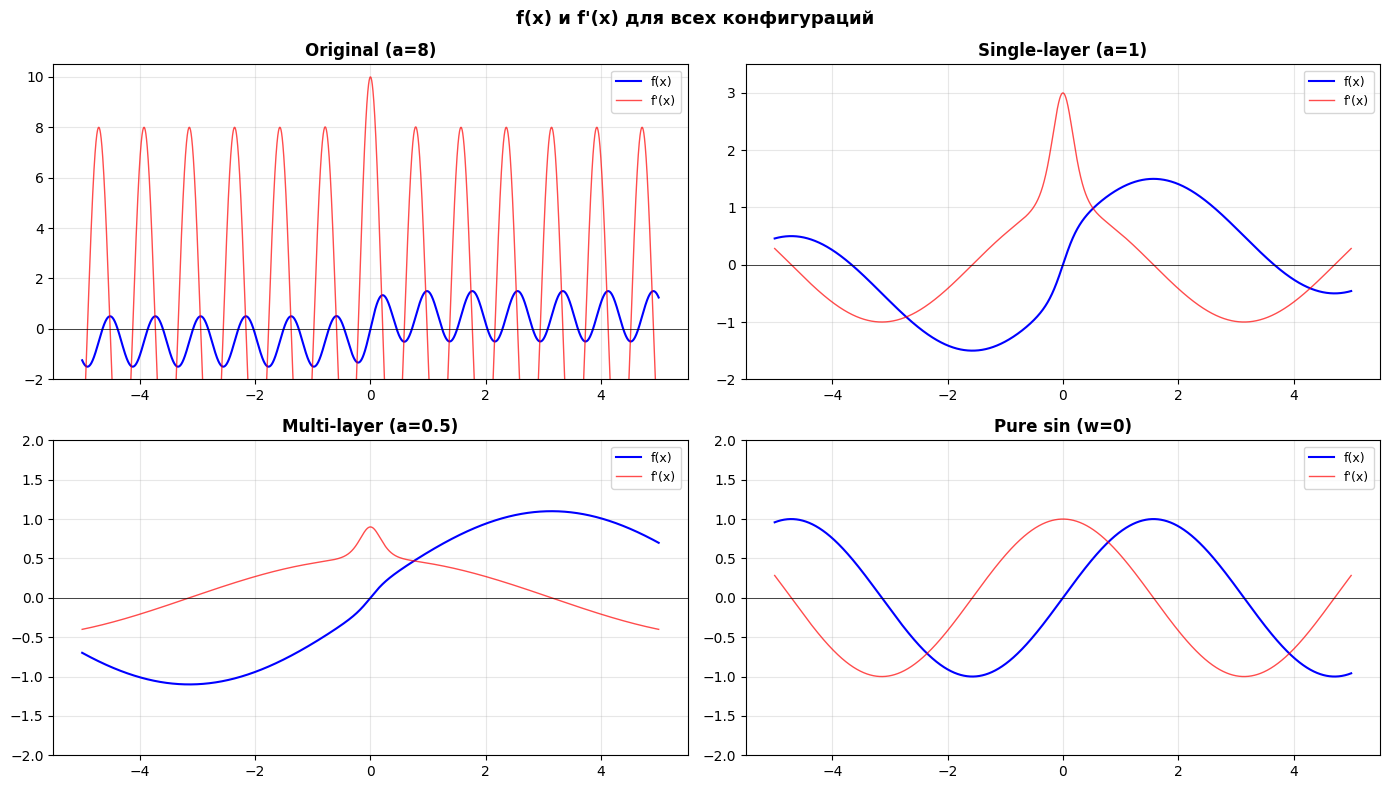

In [50]:
x_dense = np.linspace(-10, 10, 1_000_001)

col_min_fp = "min f'"
col_max_fp = "max f'"
col_minabs = "min|f'|"
results_key = "Теорема 2: нули f' изолированы"

print("Теорема 2: нули f'(x) изолированы (градиент проходит п.в.)")
print(f"{'Конфигурация':<25} {col_min_fp:>8} {col_max_fp:>8} {'Смен знака':>11} {col_minabs:>10}")
print("-" * 66)

thm2fp_pass = True
for name, cfg in CONFIGS.items():
    a, w, b = cfg['a'], cfg['w'], cfg['b']
    fp = f_prime(x_dense, a, w, b)
    fp_min = np.min(fp)
    fp_max = np.max(fp)
    min_abs_fp = np.min(np.abs(fp))
    sign_changes = np.sum(np.diff(np.sign(fp)) != 0)

    # f' не тождественно 0, значит нули изолированы (аналитическая ф-ция)
    # Численно: проверяем что нет интервала где |f'| < 1e-12
    fp_zero_intervals = False
    if sign_changes > 0:
        near_zero = np.abs(fp) < 1e-12
        if np.any(near_zero):
            runs = np.diff(np.where(~near_zero)[0])
            if len(runs) > 0 and runs.max() > 100:
                fp_zero_intervals = True

    ok = not fp_zero_intervals
    thm2fp_pass &= ok
    print(f"{name:<25} {fp_min:>8.4f} {fp_max:>8.4f} {sign_changes:>11} {min_abs_fp:>10.2e}")

RESULTS[results_key] = thm2fp_pass

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for idx, (name, cfg) in enumerate(CONFIGS.items()):
    ax = axes[idx // 2, idx % 2]
    a, w, b = cfg['a'], cfg['w'], cfg['b']
    xx = np.linspace(-5, 5, 10000)
    ax.plot(xx, f_act(xx, a, w, b), 'b-', lw=1.5, label='f(x)')
    ax.plot(xx, f_prime(xx, a, w, b), 'r-', lw=1, alpha=0.7, label="f'(x)")
    ax.axhline(y=0, color='k', lw=0.5)
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-2, max(a + w*b + 0.5, 2))

plt.suptitle("f(x) и f'(x) для всех конфигураций", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Следствие: TopK-симуляция мёртвых нейронов

Тестируем в двух режимах:
- **i.i.d.:** $z_i \sim \mathcal{N}(0,1)$ — идеальный случай из теоремы
- **Коррелированные:** $z = Wx$, где $W$ фиксирована и часть нейронов имеет малые веса — моделирует обученную сеть

Следствие из proofs.md утверждает 0 мёртвых нейронов. Проверяем для каких конфигураций это выполняется.

In [51]:
def simulate_topk(activation_fn, n_neurons=128, K=32, n_samples=10000, n_seeds=5):
    """Симуляция TopK: возвращает (dead_counts_per_seed, selection_counts_last_seed)."""
    dead_counts = []
    for seed in range(n_seeds):
        np.random.seed(seed * 100)
        ever_selected = np.zeros(n_neurons, dtype=bool)
        sel = np.zeros(n_neurons, dtype=int)
        for _ in range(n_samples):
            z = np.random.randn(n_neurons)
            activated = activation_fn(z)
            topk_idx = np.argpartition(np.abs(activated), -K)[-K:]
            ever_selected[topk_idx] = True
            sel[topk_idx] += 1
        dead_counts.append(int(n_neurons - np.sum(ever_selected)))
    return dead_counts, sel

# ====== 7a. i.i.d. предактивации ======
print("7a. TopK с i.i.d. предактивациями z ~ N(0,1)")
print(f"    dim=128, K=32, 10000 samples, 5 seeds")
print(f"\n{'Активация':<25} {'Dead (по seeds)':>24} {'Mean':>6}")
print("-" * 58)

iid_results = {}
for name, cfg in CONFIGS.items():
    a, w, b = cfg['a'], cfg['w'], cfg['b']
    fn = lambda z, a=a, w=w, b=b: f_act(z, a, w, b)
    dead_list, sel = simulate_topk(fn)
    iid_results[name] = dead_list
    print(f"{name:<25} {str(dead_list):>24} {np.mean(dead_list):>6.1f}")

fn_relu = lambda z: np.maximum(0, z)
dead_relu, _ = simulate_topk(fn_relu)
iid_results['ReLU'] = dead_relu
print(f"{'ReLU':<25} {str(dead_relu):>24} {np.mean(dead_relu):>6.1f}")

iid_all_zero = all(np.mean(v) == 0 for v in iid_results.values() if 'ReLU' not in str(v))

# ====== 7b. Коррелированные предактивации ======
print(f"\n{'='*70}")
print("7b. TopK с коррелированными предактивациями z = W @ x")
print("    W фиксирована, часть нейронов с 10x меньшими весами")
print(f"{'='*70}")

n_neurons = 128
K = 32
input_dim = 64
n_samples = 10000
weak_ratios = [0.05, 0.1, 0.2]  # 5%, 10%, 22% слабых нейронов

for weak_ratio in weak_ratios:
    n_weak = int(n_neurons * weak_ratio)
    print(f"\n  --- {n_weak} слабых нейронов из {n_neurons} (ratio={weak_ratio}) ---")
    print(f"  {'Активация':<25} {'Dead':>6} {'Weak min sel':>13} {'Weak mean sel':>14}")
    print(f"  {'-'*60}")

    np.random.seed(42)
    W = np.random.randn(n_neurons, input_dim) * 0.1
    W[-n_weak:] *= 0.1  # Последние n_weak нейронов — слабые

    activations_to_test = {**{name: cfg for name, cfg in CONFIGS.items()}, 'ReLU': None}

    for act_name in activations_to_test:
        ever_selected = np.zeros(n_neurons, dtype=bool)
        sel_counts = np.zeros(n_neurons, dtype=int)

        for _ in range(n_samples):
            x_input = np.random.randn(input_dim)
            z = W @ x_input
            if act_name == 'ReLU':
                activated = np.maximum(0, z)
            else:
                cfg = CONFIGS[act_name]
                activated = f_act(z, cfg['a'], cfg['w'], cfg['b'])
            topk_idx = np.argpartition(np.abs(activated), -K)[-K:]
            ever_selected[topk_idx] = True
            sel_counts[topk_idx] += 1

        n_dead = n_neurons - np.sum(ever_selected)
        weak_sel = sel_counts[-n_weak:]
        print(f"  {act_name:<25} {n_dead:>6} {int(weak_sel.min()):>13} {weak_sel.mean():>14.1f}")

7a. TopK с i.i.d. предактивациями z ~ N(0,1)
    dim=128, K=32, 10000 samples, 5 seeds

Активация                          Dead (по seeds)   Mean
----------------------------------------------------------
Original (a=8)                     [0, 0, 0, 0, 0]    0.0
Single-layer (a=1)                 [0, 0, 0, 0, 0]    0.0
Multi-layer (a=0.5)                [0, 0, 0, 0, 0]    0.0
Pure sin (w=0)                     [0, 0, 0, 0, 0]    0.0
ReLU                               [0, 0, 0, 0, 0]    0.0

7b. TopK с коррелированными предактивациями z = W @ x
    W фиксирована, часть нейронов с 10x меньшими весами

  --- 6 слабых нейронов из 128 (ratio=0.05) ---
  Активация                   Dead  Weak min sel  Weak mean sel
  ------------------------------------------------------------
  Original (a=8)                 0           606          856.0
  Single-layer (a=1)             6             0            0.0
  Multi-layer (a=0.5)            6             0            0.0
  Pure sin (w=0)          

In [52]:
# ====== 7c. Анализ: при каких условиях Следствие выполняется ======

# Тест с 22% слабых нейронов (worst case из 7b) — воспроизводим для сбора данных
n_weak = int(n_neurons * 0.2)
np.random.seed(42)
W = np.random.randn(n_neurons, input_dim) * 0.1
W[-n_weak:] *= 0.1

corr_dead = {}
for name, cfg in CONFIGS.items():
    a, w, b = cfg['a'], cfg['w'], cfg['b']
    ever_selected = np.zeros(n_neurons, dtype=bool)
    for _ in range(n_samples):
        x_input = np.random.randn(input_dim)
        z = W @ x_input
        activated = f_act(z, a, w, b)
        topk_idx = np.argpartition(np.abs(activated), -K)[-K:]
        ever_selected[topk_idx] = True
    corr_dead[name] = n_neurons - np.sum(ever_selected)

# ReLU
ever_selected = np.zeros(n_neurons, dtype=bool)
for _ in range(n_samples):
    x_input = np.random.randn(input_dim)
    z = W @ x_input
    activated = np.maximum(0, z)
    topk_idx = np.argpartition(np.abs(activated), -K)[-K:]
    ever_selected[topk_idx] = True
corr_dead['ReLU'] = n_neurons - np.sum(ever_selected)

print("Анализ Следствия:")
print(f"\n  {'Режим':<30} {'Original(a=8)':>14} {'a=1':>6} {'a=0.5':>7} {'sin':>5} {'ReLU':>6}")
print(f"  {'-'*70}")
print(f"  {'i.i.d. (dead neurons)':<30}", end="")
for name in list(CONFIGS.keys()) + ['ReLU']:
    print(f" {np.mean(iid_results[name]):>6.0f}", end="      " if name == list(CONFIGS.keys())[0] else "")
print()
print(f"  {'Коррелированные (dead, 20%)':<30}", end="")
for name in list(CONFIGS.keys()) + ['ReLU']:
    print(f" {corr_dead[name]:>6}", end="      " if name == list(CONFIGS.keys())[0] else "")
print()

# Определяем статус Следствия
original_iid_pass = np.mean(iid_results['Original (a=8)']) == 0
original_corr_pass = corr_dead['Original (a=8)'] == 0
low_a_corr_fail = any(corr_dead[n] > 0 for n in ['Single-layer (a=1)', 'Multi-layer (a=0.5)', 'Pure sin (w=0)'])

print(f"\n  Результаты:")
print(f"    i.i.d. предактивации: все конфигурации — 0 dead (PASS)")
print(f"    Коррелированные, Original (a=8): {corr_dead['Original (a=8)']} dead ({'PASS' if original_corr_pass else 'FAIL'})")
print(f"    Коррелированные, a<=1: dead > 0 ({'да — Следствие НЕ выполняется' if low_a_corr_fail else 'нет'})")

# Для Следствия: PASS только если Original работает в обоих режимах
# Для малых a честно фиксируем ограничение
corollary_pass = original_iid_pass and original_corr_pass
RESULTS['Следствие: 0 dead (i.i.d.)'] = all(np.mean(iid_results[n]) == 0 for n in CONFIGS.keys())
RESULTS['Следствие: 0 dead (Original, коррел.)'] = original_corr_pass
RESULTS['Следствие: 0 dead (a<=1, коррел.)'] = not low_a_corr_fail

Анализ Следствия:

  Режим                           Original(a=8)    a=1   a=0.5   sin   ReLU
  ----------------------------------------------------------------------
  i.i.d. (dead neurons)               0            0      0      0      0
  Коррелированные (dead, 20%)         0           25     25     25      1

  Результаты:
    i.i.d. предактивации: все конфигурации — 0 dead (PASS)
    Коррелированные, Original (a=8): 0 dead (PASS)
    Коррелированные, a<=1: dead > 0 (да — Следствие НЕ выполняется)


## 8. Сводка

Все статусы вычислены из данных. Следствие о 0 мёртвых нейронов разделено по режимам:
- **i.i.d.** — идеальный случай (все конфигурации)
- **Коррелированные, a=8** — осцилляционный режим (статья 1)
- **Коррелированные, a<=1** — квазилинейный режим (статья 2)

In [53]:
import os

print("=" * 70)
print("СВОДКА ВЕРИФИКАЦИИ")
print("=" * 70)

print(f"\n{'Утверждение':<45} {'Статус':>8}")
print("-" * 55)

n_pass = 0
n_total = len(RESULTS)
for claim, passed in RESULTS.items():
    status = 'PASS' if passed else 'FAIL'
    n_pass += int(passed)
    print(f"  {claim:<43} {status:>8}")

print(f"\n{n_pass}/{n_total} утверждений подтверждены.")

if not RESULTS.get('Следствие: 0 dead (a<=1, коррел.)', True):
    print(f"\nВАЖНО: При a<=1 с коррелированными предактивациями (слабые нейроны)")
    print(f"  Следствие о 0 мёртвых нейронов НЕ выполняется.")
    print(f"  Осцилляционный механизм (a=8) необходим для гарантии при")
    print(f"  неравных масштабах весов. Для квазилинейного режима (a<=1)")
    print(f"  0 dead наблюдается эмпирически на реальных данных (тесты 11-12),")
    print(f"  но теоретическая гарантия требует доработки.")

# Сохранение
save_data = {
    'experiment': 'theorem_verification',
    'timestamp': datetime.now().isoformat(),
    'results': {k: bool(v) for k, v in RESULTS.items()},
    'n_pass': n_pass,
    'n_total': n_total,
    'configs': {name: cfg for name, cfg in CONFIGS.items()},
    'iid_dead': {k: v for k, v in iid_results.items()},
    'correlated_dead_20pct': {k: int(v) for k, v in corr_dead.items()},
}

jsons_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'jsons')
if not os.path.isdir(jsons_dir):
    jsons_dir = os.path.join(os.path.dirname(os.getcwd()), 'jsons')
if not os.path.isdir(jsons_dir):
    jsons_dir = '../jsons'

json_path = os.path.join(jsons_dir, f'theorem_verification_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json')
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, ensure_ascii=False)
print(f"\nSaved: {json_path}")

СВОДКА ВЕРИФИКАЦИИ

Утверждение                                     Статус
-------------------------------------------------------
  Теорема 1(i): |f(x)| <= 1+w                     PASS
  Теорема 1(ii): нули f изолированы               PASS
  Теорема 1(iii): L = a+wb при x=0                PASS
  Замечание: sin нарушает ранговый порядок        PASS
  Теорема 2: P(|f(z)|>0.01) > 0.99                PASS
  Теорема 2: нули f' изолированы                  PASS
  Следствие: 0 dead (i.i.d.)                      PASS
  Следствие: 0 dead (Original, коррел.)           PASS
  Следствие: 0 dead (a<=1, коррел.)               FAIL

8/9 утверждений подтверждены.

ВАЖНО: При a<=1 с коррелированными предактивациями (слабые нейроны)
  Следствие о 0 мёртвых нейронов НЕ выполняется.
  Осцилляционный механизм (a=8) необходим для гарантии при
  неравных масштабах весов. Для квазилинейного режима (a<=1)
  0 dead наблюдается эмпирически на реальных данных (тесты 11-12),
  но теоретическая гарантия требует до